## **Variables correlation**

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
EEA = pd.read_csv('reduced_EEA_2023_conservative.csv')

In [3]:
EEA = EEA.drop("index", axis=1)

In [4]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,1175.0,129.0,petrol,999.0,70.0
1,1122.0,117.0,petrol,999.0,59.0
2,1588.0,126.0,diesel,1968.0,110.0
3,1516.0,124.0,diesel,1968.0,110.0
4,1349.0,126.0,petrol,1498.0,110.0


In [5]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48449 entries, 0 to 48448
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Mass_in_Running_Order(kg)  48449 non-null  float64
 1   CO2_Emissions_WLTP(g/km)   48449 non-null  float64
 2   Fuel_Type                  48449 non-null  object 
 3   Engine_Capacity(cm3)       48449 non-null  float64
 4   Engine_Power(kW)           48449 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.8+ MB


So, we have 4 numerical values and one categorical

we should look at the distribution of our numerical features so we can know which scaler to apply

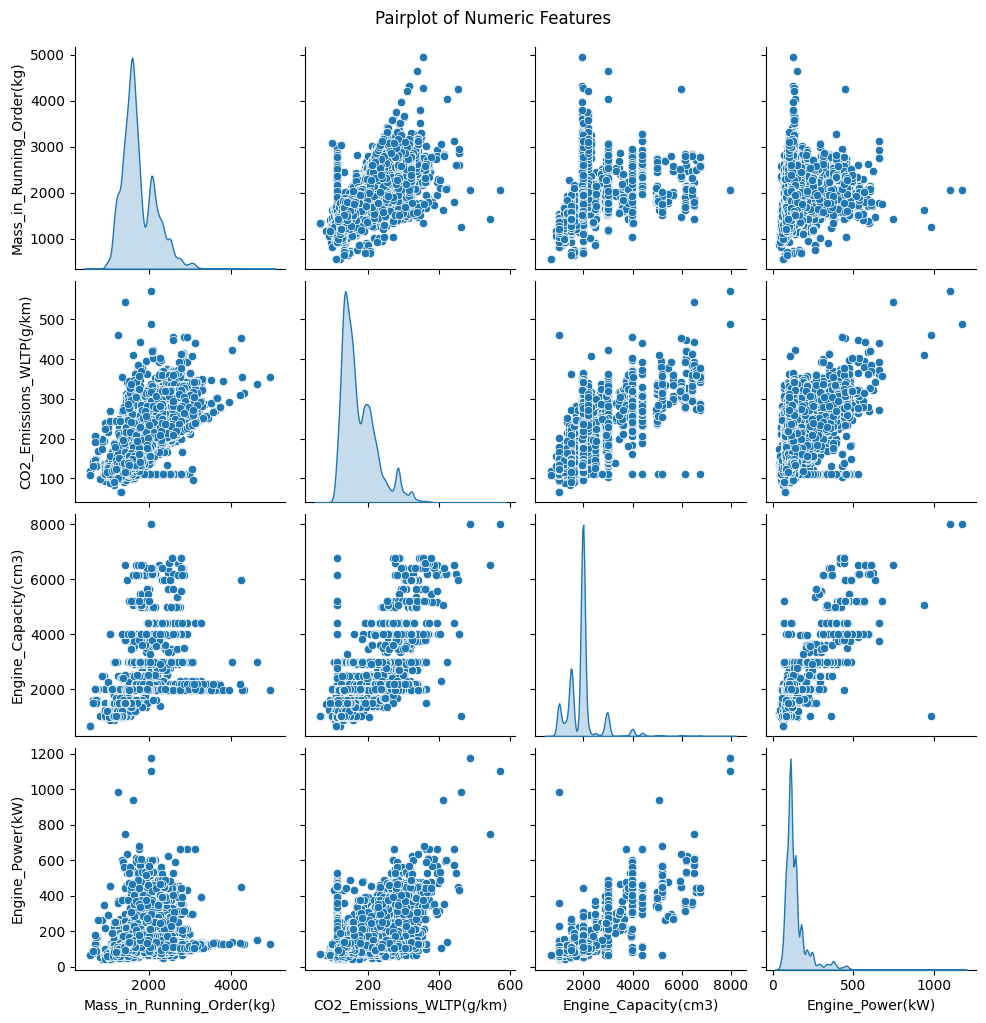

In [6]:
# Optional: Reduce number of samples if dataset is large
sns.pairplot(EEA, diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()


Mass:
 - Distribution: Right-skewed (positive skew)
 - Observations:
    - Clustered around 1000–2000 kg
    - Long tail to heavier vehicles (>2000 kg)
    - Likely outliers in the upper range

Engine capacity: 
  - Distribution: Right-skewed, but not heavily
  - Observations:
    - Looks like it has discrete bands. This is because vehicles share the exact same engine size due to the design norms, even though it’s a continuous variable
    - Clustering around typical engine sizes (1000, 1600, 2000, 3000 cm³)
    - Gaps between these clusters — not a smooth histogram

Engine_Power(kW):
  - Distribution: Heavily right skweed
  - Observations: 
    - Most vehicles are in the 50–150 kW range
    - Extreme outliers above 300–400 kW (likely high-performance cars)
    - These outliers will influence most models

 CO2_Emissions_WLTP(g/km):
  - Distribution: Also right-skewed
  - Observations:
    - Many vehicles emit between 100–200 g/km
    - Some go well above 250–300 g/km












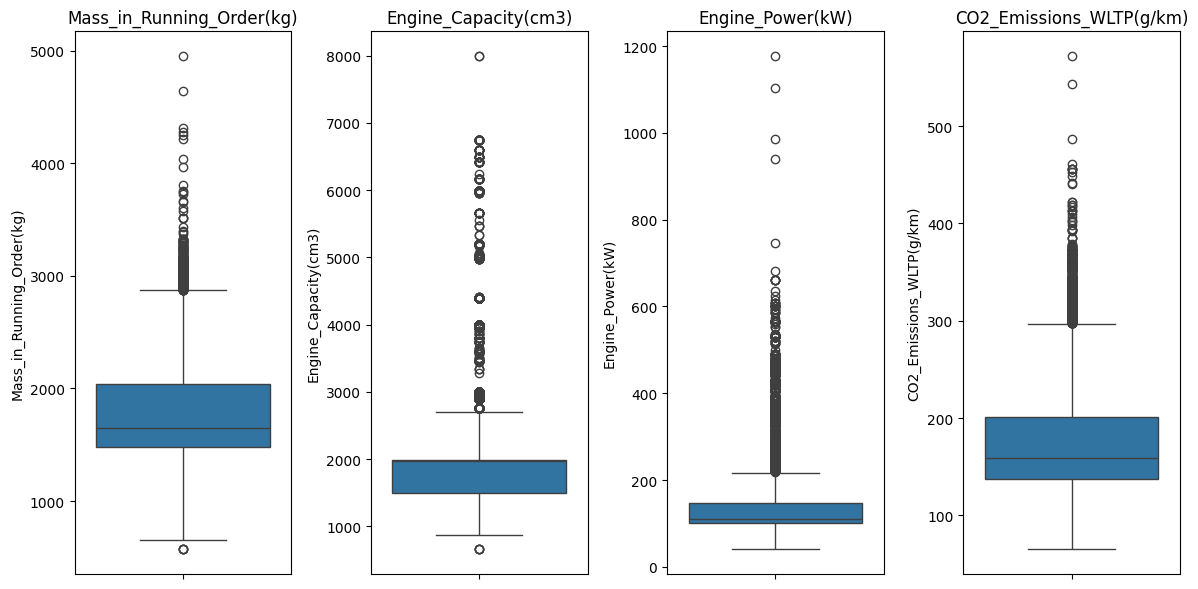

In [7]:

numeric_cols = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 
                'Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=EEA[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

### What does the Fuel type distribution look like?

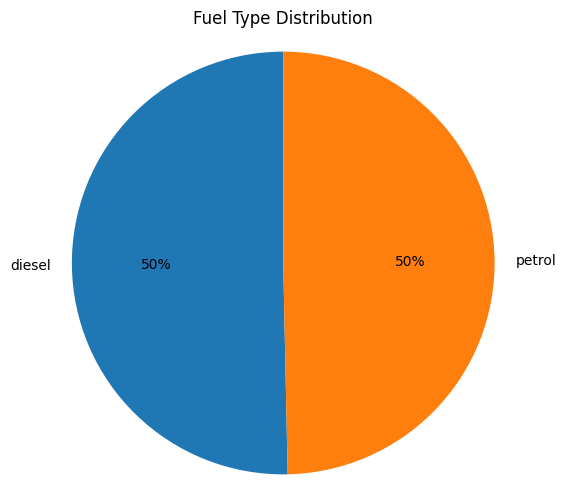

In [8]:

# Get value counts
fuel_counts = EEA['Fuel_Type'].value_counts(normalize=True)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.0f%%', startangle=90)
plt.title('Fuel Type Distribution')
plt.axis('equal')  # Makes the pie chart a circle
plt.show()

Let's explore how our variables are explaining our target

## Categorical into dummies

In [9]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [10]:
EEA = EEA.astype(int)

In [11]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


In [12]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48449 entries, 0 to 48448
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Mass_in_Running_Order(kg)  48449 non-null  int64
 1   CO2_Emissions_WLTP(g/km)   48449 non-null  int64
 2   Engine_Capacity(cm3)       48449 non-null  int64
 3   Engine_Power(kW)           48449 non-null  int64
 4   Fuel_Type_petrol           48449 non-null  int64
dtypes: int64(5)
memory usage: 1.8 MB


## Model 1 - Linear Regression

In [13]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])



Train MSE (LR): 501.43
Test MSE (LR): 499.27
Train MAE (LR): 14.09
Test MAE (LR): 14.06
Train RMSE (LR): 22.39
Test RMSE (LR): 22.34
Train R² Score (LR): 0.789
Test R² Score (LR): 0.786


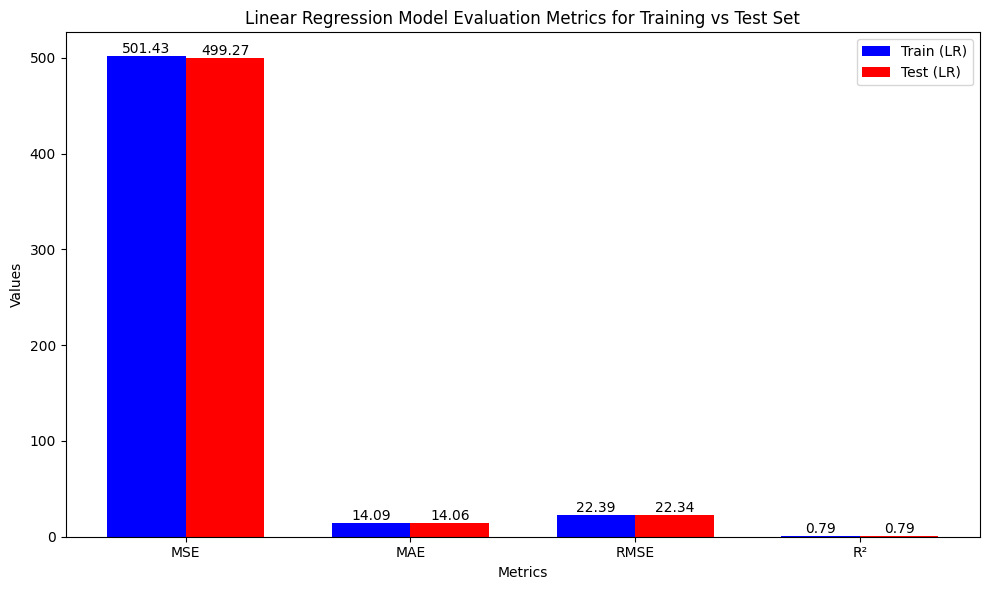

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model_scaled = LinearRegression()
lr_model_scaled.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model_scaled.predict(X_train_scaled)
y_test_pred_lr = lr_model_scaled.predict(X_test_scaled)

train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)

train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

train_mrse_lr = np.sqrt(train_mse_lr)
test_mrse_lr = np.sqrt(test_mse_lr)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print(f"Train MSE (LR): {train_mse_lr:.2f}")
print(f"Test MSE (LR): {test_mse_lr:.2f}")
print(f"Train MAE (LR): {train_mae_lr:.2f}")
print(f"Test MAE (LR): {test_mae_lr:.2f}")
print(f"Train RMSE (LR): {train_mrse_lr:.2f}")
print(f"Test RMSE (LR): {test_mrse_lr:.2f}")
print(f"Train R² Score (LR): {train_r2_lr:.3f}")
print(f"Test R² Score (LR): {test_r2_lr:.3f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values_lr = [train_mse_lr, train_mae_lr, train_mrse_lr, train_r2_lr]
test_values_lr = [test_mse_lr, test_mae_lr, test_mrse_lr, test_r2_lr]

bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values_lr, bar_width, label='Train (LR)', color='blue')
plt.bar(index + bar_width, test_values_lr, bar_width, label='Test (LR)', color='red')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Linear Regression Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

for i, value in enumerate(train_values_lr):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values_lr):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    39.405370
3           Fuel_Type_petrol    22.871745
2           Engine_Power(kW)    11.357583
1       Engine_Capacity(cm3)     2.031584


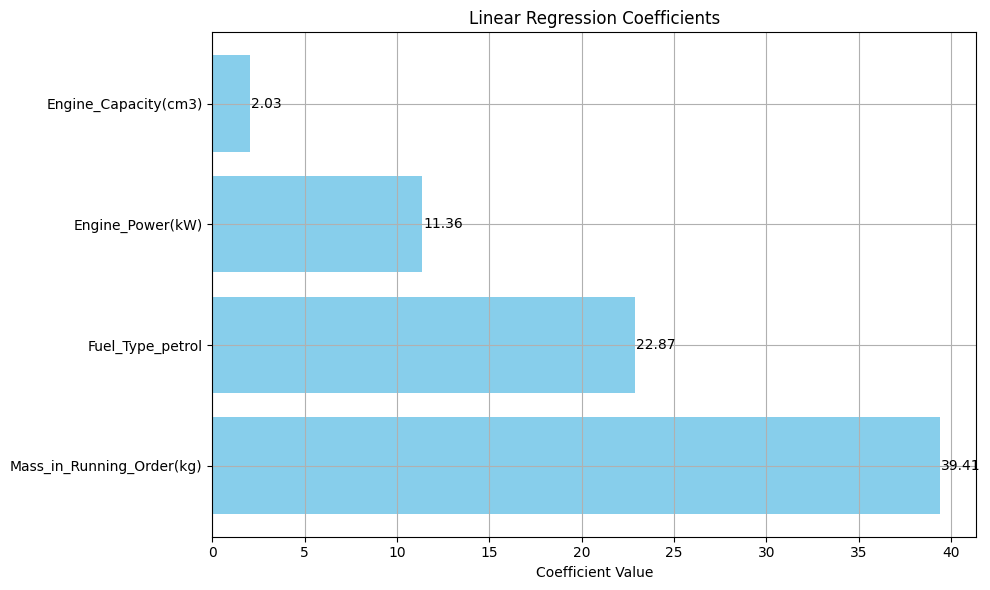

In [17]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model_scaled.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
train_test_diff = abs(train_r2_lr - test_r2_lr)
print(f"Train R²: {train_r2_lr:.3f}")
print(f"Test R²: {test_r2_lr:.3f}")
print(f"R² Difference: {train_test_diff:.3f}")

if train_test_diff > 0.05:
    print("⚠️  Potential overfitting detected")
elif test_r2_lr > train_r2_lr:
    print("✅ No overfitting - good generalization")
else:
    print("✅ Good fit - minimal overfitting")

Train R²: 0.789
Test R²: 0.786
R² Difference: 0.003
✅ Good fit - minimal overfitting


- R² Score: 0.79
    - This means 79% of the variance in CO₂ emissions is explained by the model. That’s a strong result for a linear model, especially considering the simplicity and interpretability.

The model generalizes well and isn't heavily overfitting as the R2 difference is 0.003.

- Mass_in_Running_Order is the Strongest predictor. Heavier vehicles emit more CO₂
- The next strongest predictor is Fuel_Type_petrol. Petrol cars emit significantly more than diesel (since "petrol = 1")
- The weakest impact is the Engine_Capacity(cm3), which indicates that might be redundant with power or mass

## Model 2 - Lasso model

In [19]:
from sklearn.linear_model import Lasso

In [20]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])


In [23]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


Lasso Test MSE: 499.35
Lasso Test MAE: 14.06
Lasso Test RMSE: 22.35
Lasso Test R²: 0.786


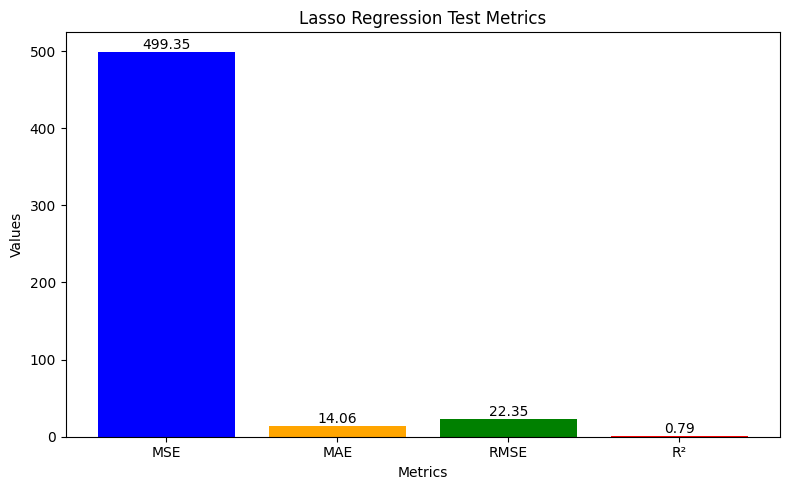

In [24]:
y_pred = lasso_model.predict(X_test_scaled)

# Calculate MSE, MAE, RMSE, and R²
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics
print(f"Lasso Test MSE: {mse:.2f}")
print(f"Lasso Test MAE: {mae:.2f}")
print(f"Lasso Test RMSE: {mrse:.2f}")
print(f"Lasso Test R²: {r2:.3f}")

# Prepare data for the graph
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])

# Add the values on top of the bars
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Lasso Regression Test Metrics')

# Show the graph
plt.tight_layout()
plt.show()

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    39.139166
3           Fuel_Type_petrol    22.089590
2           Engine_Power(kW)    11.596605
1       Engine_Capacity(cm3)     1.833783


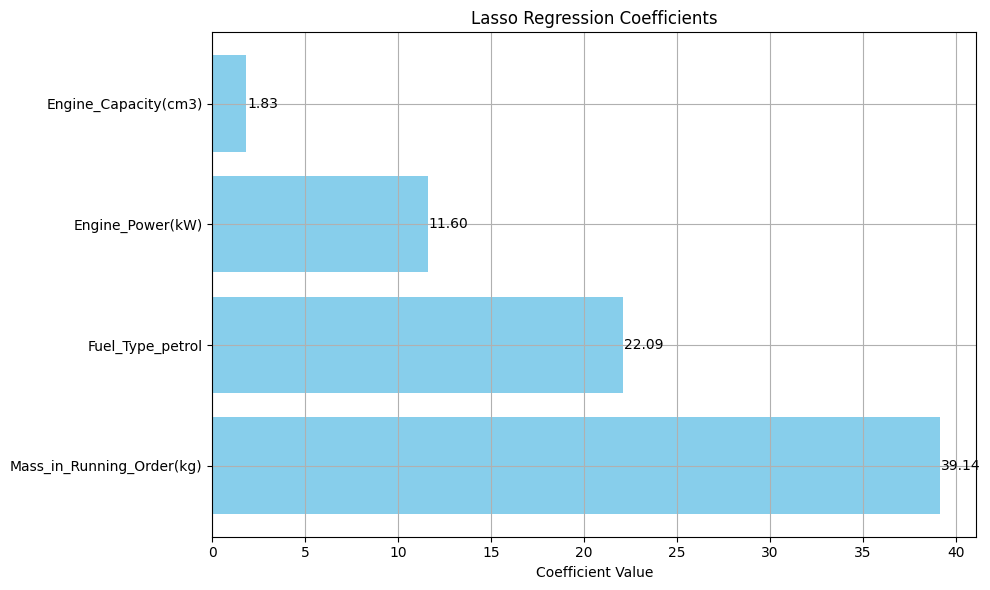

In [25]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

# Plotting the coefficients
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='skyblue')

# Adding the coefficient values on the bars
for i, v in enumerate(coefficients['Coefficient']):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', ha='left', color='black')

plt.xlabel('Coefficient Value')
plt.title('Lasso Regression Coefficients')
plt.grid(True)
plt.tight_layout()
plt.show()

Best alpha: 0.00013257113655901095
Test MSE: 499.2711315501242
Lasso Test RMSE: 22.34
Test R²: 0.7863757622806924


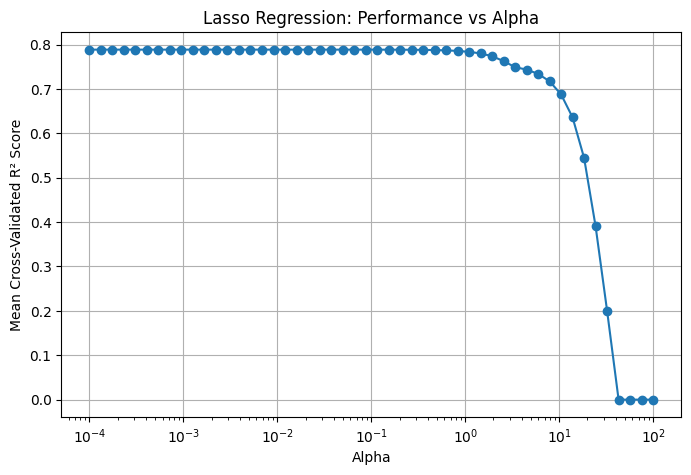

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 4. Define Lasso model and alpha grid
lasso = Lasso(max_iter=10000)
alphas = {'alpha': np.logspace(-4, 2, 50)}  # alpha values from 0.0001 to 100

# 5. Grid search for best alpha
grid = GridSearchCV(lasso, alphas, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

# 6. Best model evaluation
best_lasso = grid.best_estimator_
y_pred = best_lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mrse = np.sqrt(mse)

print("Best alpha:", grid.best_params_['alpha'])
print("Test MSE:", mse)
print(f"Lasso Test RMSE: {mrse:.2f}")
print("Test R²:", r2)

# 7. Plot alpha vs CV R²
plt.figure(figsize=(8, 5))
plt.semilogx(alphas['alpha'], grid.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Lasso Regression: Performance vs Alpha')
plt.grid(True)
plt.show()



The results are very similar to Linear Model above.

## Model 3 - RandomForestRegressor 

RandomForestRegressor does not require scaling or normalization

Test MSE: 186.53
Test MAE: 6.19
Test RMSE: 13.66
Test R² Score: 0.920


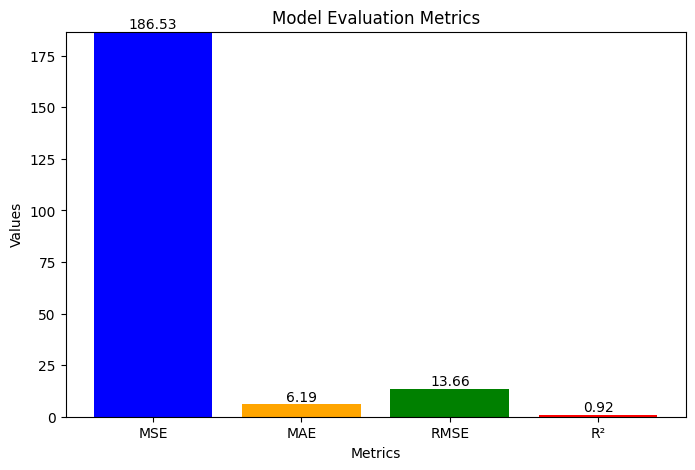

In [45]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# 2. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mrse = np.sqrt(mse)  # Root Mean Squared Error

r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {mrse:.2f}")
print(f"Test R² Score: {r2:.3f}")

# 6. Visualize the metrics on a graph
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, mrse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()

R² score of 0.92 is very good, because it means that the model can explain 92% of the data variance. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 84.54
Test MSE: 186.53
Train MAE: 4.62
Test MAE: 6.19
Train RMSE: 9.19
Test RMSE: 13.66
Train R² Score: 0.964
Test R² Score: 0.920


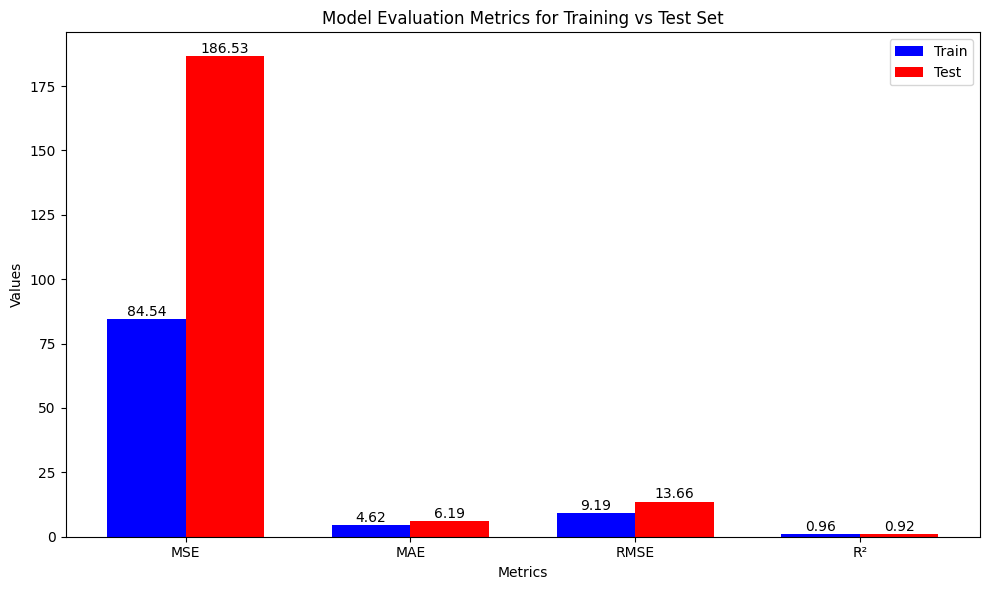

In [46]:
# 1. Predictions for Training and Test Set
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.96 shows it explains 96% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.92, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

In oder to get a higher confidence in our results, we perform a cross-validation

In [47]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.92469713 0.91582501 0.91969231 0.91266161 0.91634753]
Mean CV R² score: 0.918


- Consistent performance: Scores range from 0.912 to 0.924. This suggests model's performance is very good across different data splits.

- No severe overfitting:
    Test R² (0.92), train R² (0.96), and CV R² (0.92) are all close. The R² difference (0.04) is acceptable and suggests minimal overfitting.

- Model status: The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2],
}

# Initialize the base model
rf = RandomForestRegressor(random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9203443254482873


In [49]:
# Best parameters and R² from GridSearchCV
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# Best estimator
best_model_Random_Forest = grid_search.best_estimator_

# Predictions
y_train_pred = best_model_Random_Forest.predict(X_train)
y_test_pred = best_model_Random_Forest.predict(X_test)

# --- Train metrics ---
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# --- Test metrics ---
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# --- Print results ---
print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validated R² score: 0.9203443254482873



Fine-tuned Model Performance:
Train MSE: 105.982
Train RMSE: 10.295
Train MAE: 5.208
Train R²: 0.955

Test MSE: 176.837
Test RMSE: 13.298
Test MAE: 6.227
Test R²: 0.924


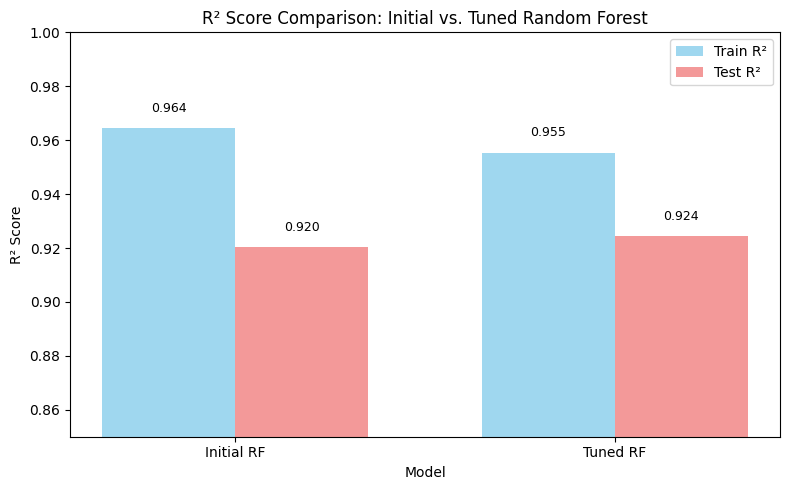

In [50]:
#Model Comparison and Evaluation

# Step 1: Calculate R² scores
initial_train_r2 = r2_score(y_train, rf_model.predict(X_train))
initial_test_r2 = r2_score(y_test, rf_model.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_Random_Forest.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_Random_Forest.predict(X_test))

# Step 2: Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Initial RF', 'Tuned RF'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

# Step 3: Plot
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

# Bar plot
axes.bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')

# Formatting
axes.set_xlabel('Model')
axes.set_ylabel('R² Score')
axes.set_title('R² Score Comparison: Initial vs. Tuned Random Forest')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



We observe slight improvement with hyperparameter optimization on CV R2 scores. We didn't expect more as it is already performing good

## Model 4 - XGBoost model

XGBoost does not require scaling or normalization

In [51]:
from xgboost import XGBRegressor   


In [52]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Basic Model Performance:
MSE: 197.75
RMSE: 14.06
R² Score: 0.915
MAE: 7.36


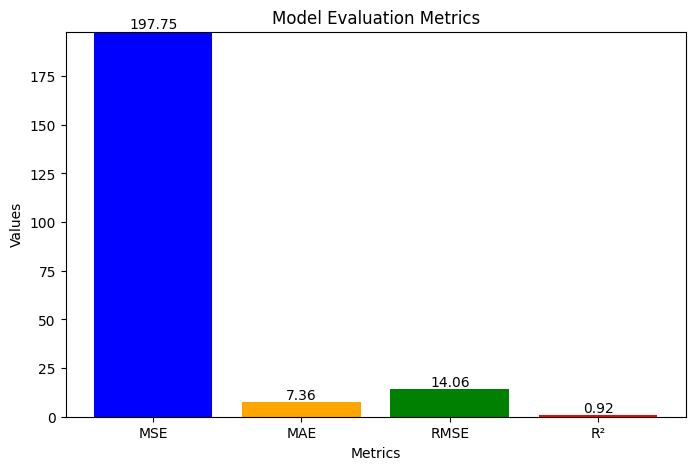

In [54]:
xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train, y_train)
y_pred_basic = xgb_basic.predict(X_test)

# Basic model evaluation
mse_basic = mean_squared_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test, y_pred_basic))
r2_basic = r2_score(y_test, y_pred_basic)
mae_basic = mean_absolute_error(y_test, y_pred_basic)


print(f"Basic Model Performance:")
print(f"MSE: {mse_basic:.2f}")
print(f"RMSE: {rmse_basic:.2f}")
print(f"R² Score: {r2_basic:.3f}")
print(f"MAE: {mae_basic:.2f}")

metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse_basic, mae_basic, rmse_basic, r2_basic]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()



R² score of 0.92 is very good, because it means that the model can explain 92% of the data variance. 

These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

Train MSE: 143.26
Test MSE: 197.75
Train MAE: 6.73
Test MAE: 7.36
Train RMSE: 11.97
Test RMSE: 14.06
Train R² Score: 0.940
Test R² Score: 0.915


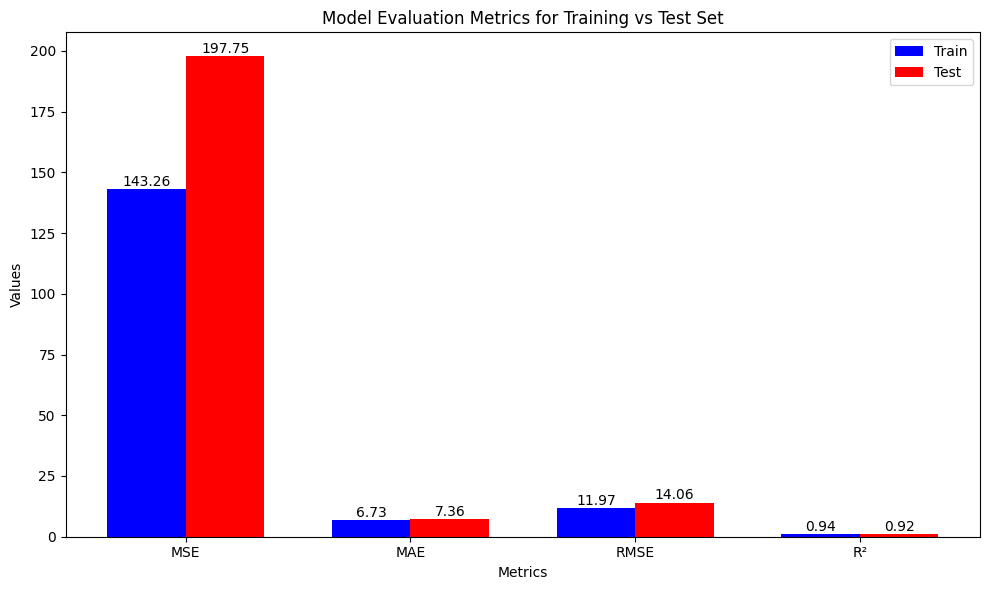

In [55]:
# 1. Predictions for Training and Test Set
y_train_pred = xgb_basic.predict(X_train)
y_test_pred = xgb_basic.predict(X_test)

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mrse = np.sqrt(train_mse)
test_mrse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_mrse:.2f}")
print(f"Test RMSE: {test_mrse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_mrse, train_r2]
test_values = [test_mse, test_mae, test_mrse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Evaluation Metrics for Training vs Test Set')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

The training set has very low MSE, MAE, and RMSE, indicating the model fits the training data well, while the R² score of 0.95 shows it explains 95% of the variance in the training set.
The test set shows slightly higher MSE, MAE, and especially in RMSE values, and the R² score is 0.92, suggesting that the model generalizes well but may still be overfitting slightly to the training data.

- The model captures the underlying relationship between vehicle characteristics and CO2 emissions very well
- Performance is consistent between training and test sets (no severe overfitting)
- Error levels are practically acceptable for most applications

However, The mild overfitting suggests hyperparameter tuning could help

In [56]:
cv_scores = cross_val_score(xgb_basic, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.3f}")

Cross-validated R² scores: [0.92210162 0.91354054 0.91699207 0.90613884 0.91020274]
Mean CV R² score: 0.914


We see very similar pattern as Random Forest Model results. 

The overall performance of the model is strong. The model is well fitted and generalizes well. 

#### Hyperparameter Tuning

In [57]:

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'reg_alpha': [0.1, 1, 10],
    'reg_lambda': [1, 10, 100],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize XGBoost regressor

xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_basic,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Print best parameters and R² score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)


Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9180501461029053


In [58]:
# Best parameters and R² from GridSearchCV
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# Best estimator
best_model_XGBoost = grid_search.best_estimator_

# Predictions
y_train_pred = best_model_XGBoost.predict(X_train)
y_test_pred = best_model_XGBoost.predict(X_test)

# --- Train metrics ---
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# --- Test metrics ---
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# --- Print results ---
print("\nFine-tuned Model Performance:")
print(f"Train MSE: {train_mse:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest MSE: {test_mse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R²: {test_r2:.3f}")

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 1.0}
Best cross-validated R² score: 0.9180501461029053

Fine-tuned Model Performance:
Train MSE: 142.724
Train RMSE: 11.947
Train MAE: 6.564
Train R²: 0.940

Test MSE: 193.329
Test RMSE: 13.904
Test MAE: 7.152
Test R²: 0.917


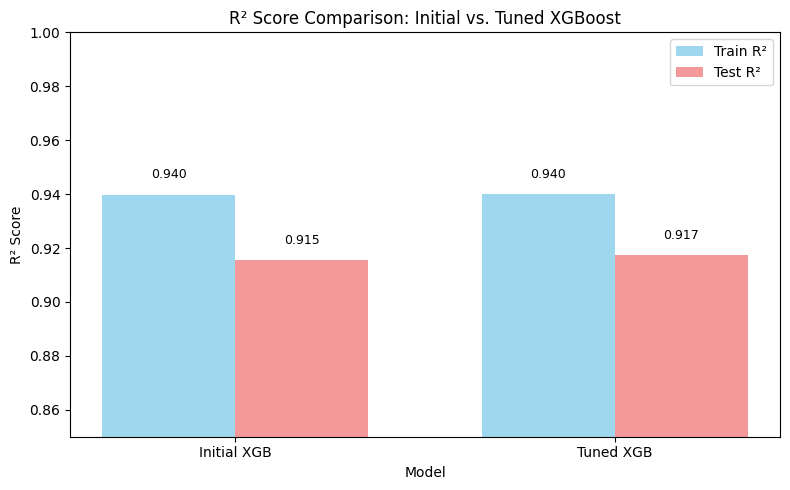

In [59]:
#Model Comparison and Evaluation

xgb_basic = XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train, y_train)
y_pred_basic = xgb_basic.predict(X_test)

# Step 1: Calculate R² scores
initial_train_r2 = r2_score(y_train, xgb_basic.predict(X_train))
initial_test_r2 = r2_score(y_test, xgb_basic.predict(X_test))
tuned_train_r2 = r2_score(y_train, best_model_XGBoost.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_model_XGBoost.predict(X_test))

# Step 2: Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Initial XGB', 'Tuned XGB'],
    'Train_R2': [initial_train_r2, tuned_train_r2],
    'Test_R2': [initial_test_r2, tuned_test_r2]
})

# Step 3: Plot
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
models_names = comparison_df['Model']
train_r2_vals = comparison_df['Train_R2']
test_r2_vals = comparison_df['Test_R2']

x = np.arange(len(models_names))
width = 0.35

# Bar plot
axes.bar(x - width/2, train_r2_vals, width, label='Train R²', alpha=0.8, color='skyblue')
axes.bar(x + width/2, test_r2_vals, width, label='Test R²', alpha=0.8, color='lightcoral')

# Formatting
axes.set_xlabel('Model')
axes.set_ylabel('R² Score')
axes.set_title('R² Score Comparison: Initial vs. Tuned XGBoost')
axes.set_xticks(x)
axes.set_xticklabels(models_names)
axes.legend()
axes.set_ylim([0.85, 1.0])

# Add values on bars
for i, (train_val, test_val) in enumerate(zip(train_r2_vals, test_r2_vals)):
    axes.text(i - width/2, train_val + 0.005, f'{train_val:.3f}', 
              ha='center', va='bottom', fontsize=9)
    axes.text(i + width/2, test_val + 0.005, f'{test_val:.3f}', 
              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

We have seen a slight overfitting reduction after hyperparameter tuning, but that also costs us some performance degradation. 


## Model 5 - Deeplearning model

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [28]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1. Define features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# 2. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the neural network model

dl_model = Sequential()
# Input layer
dl_model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

# Hidden layers
dl_model.add(Dense(128, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(64, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.1))

# Output layer
dl_model.add(Dense(1, activation='linear'))  # Linear for regression

# 5. Compile the model
dl_model.compile(optimizer=Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='mse', metrics=['mae'])

# Display model architecture
print("Model Architecture:")
dl_model.summary()

# 5. Setup callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.8,
    patience=15,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# 6. Train the model
history = dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# 7. Make predictions
y_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# 8. Calculate evaluation metrics (same as your RF model)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics (same format as your RF model)
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.3f}")


Model Architecture:


/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 30095.2383 - mae: 166.4459 - val_loss: 18781.9062 - val_mae: 122.3705 - learning_rate: 5.0000e-04
Epoch 2/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16536.8594 - mae: 109.2157 - val_loss: 4396.7178 - val_mae: 38.4075 - learning_rate: 5.0000e-04
Epoch 3/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4157.5859 - mae: 49.0682 - val_loss: 1105.9608 - val_mae: 24.0114 - learning_rate: 5.0000e-04
Epoch 4/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2375.5288 - mae: 37.1170 - val_loss: 1000.2698 - val_mae: 23.1059 - learning_rate: 5.0000e-04
Epoch 5/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1996.9141 - mae: 33.6009 - val_loss: 799.7018 - val_mae: 20.0710 - learning_rate: 5.0000e-04
Epoch 6/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1820.7355 - mae: 31.7845 - val_loss: 668.7700 - val_mae: 18.6132 - learning_rate: 5.0000e-04
Epoch 7/200
485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1716.

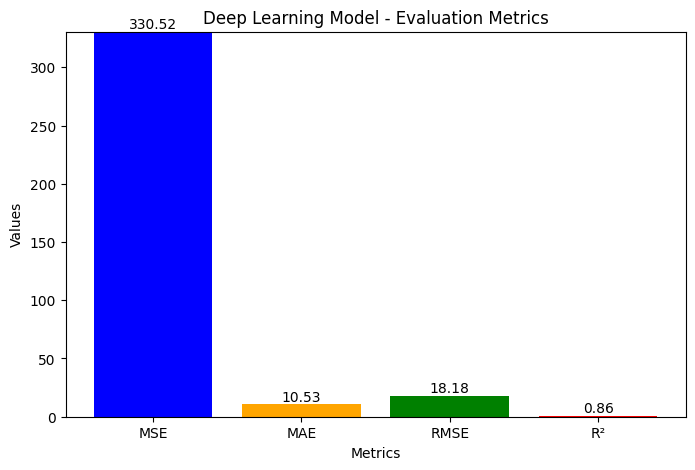

In [29]:
# 9. Visualize the metrics (same style as your RF model)
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, rmse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Deep Learning Model - Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()

Train MSE: 360.34
Test MSE: 330.52
Train MAE: 10.45
Test MAE: 10.53
Train RMSE: 18.98
Test RMSE: 18.18
Train R² Score: 0.848
Test R² Score: 0.859


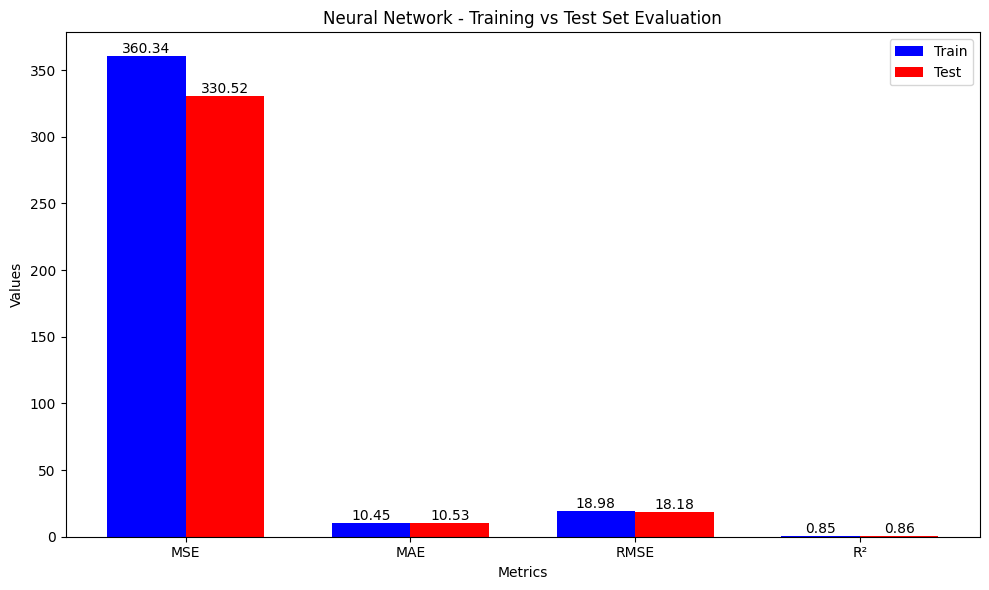

In [30]:

# 1. Predictions for Training and Test Set
y_train_pred = dl_model.predict(X_train_scaled, verbose=0).flatten()
y_test_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Neural Network - Training vs Test Set Evaluation')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



We don't see much difference between training & validation results for MSE, MAE, and RMSE, indicating the model generalizes well, while the R² score of 0.87 shows it explains 87% of the variance in the training set.

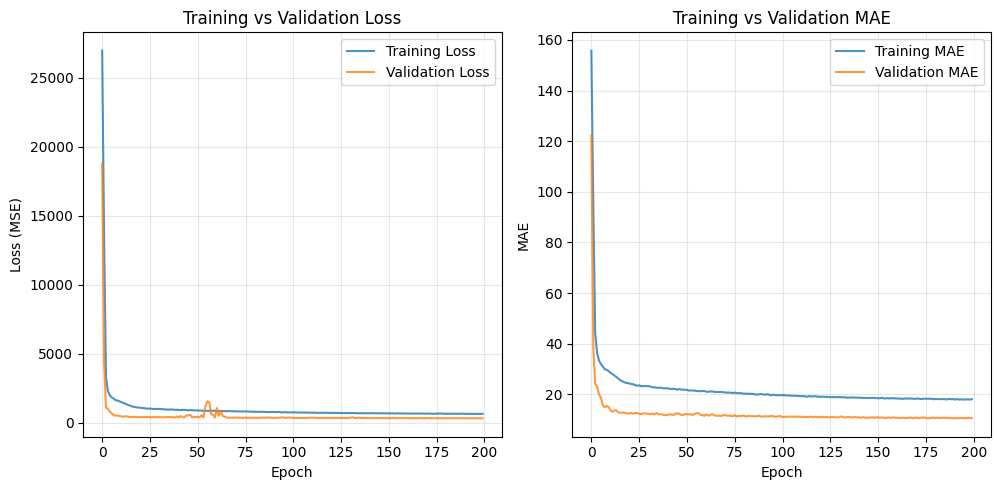

In [31]:

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss', alpha=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', alpha=0.8)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', alpha=0.8)
plt.plot(history.history['val_mae'], label='Validation MAE', alpha=0.8)
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate schedule
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Calculating feature importance (this may take a moment)...
Feature Importance Rankings:
Mass_in_Running_Order(kg): 1.4153
Engine_Capacity(cm3): 0.8292
Fuel_Type_petrol: 0.3631
Engine_Power(kW): 0.1776


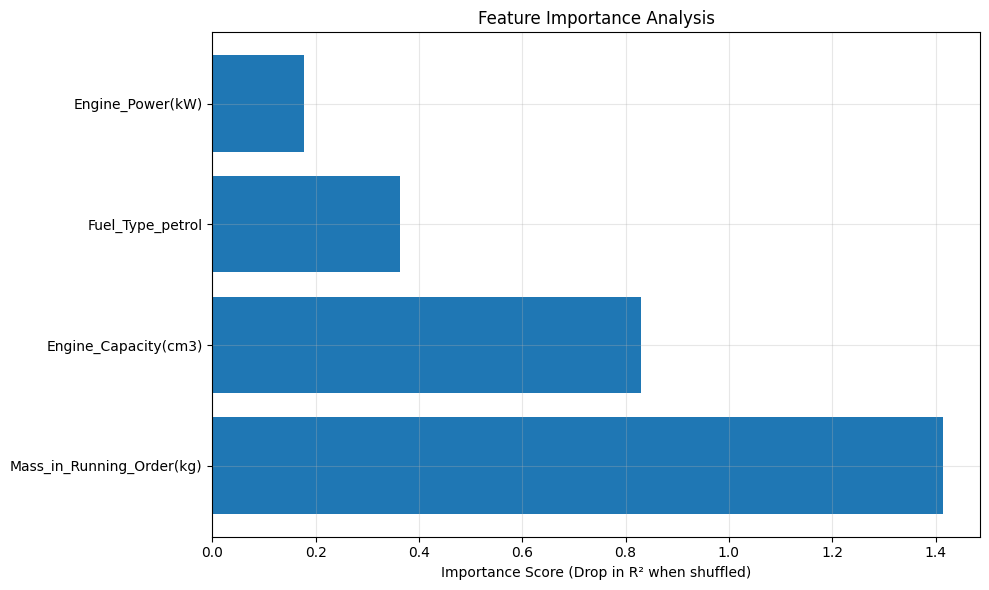

In [32]:
# Feature Importance Analysis

# Simple feature importance using permutation
feature_names = X.columns.tolist()
baseline_score = r2_score(y_test, y_pred)
feature_importance = []

print("Calculating feature importance (this may take a moment)...")
for i, feature in enumerate(feature_names):
    # Create a copy and shuffle one feature
    X_test_permuted = X_test_scaled.copy()
    np.random.shuffle(X_test_permuted[:, i])
    
    # Get predictions with shuffled feature
    y_pred_permuted = dl_model.predict(X_test_permuted, verbose=0).flatten()
    permuted_score = r2_score(y_test, y_pred_permuted)
    
    # Importance = drop in performance
    importance = baseline_score - permuted_score
    feature_importance.append(importance)

# Create feature importance dataframe
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
for idx, row in feature_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_df)), feature_df['Importance'])
plt.yticks(range(len(feature_df)), feature_df['Feature'])
plt.xlabel('Importance Score (Drop in R² when shuffled)')
plt.title('Feature Importance Analysis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## <span style="color:orange">Model Comparison & Conclusions</span>

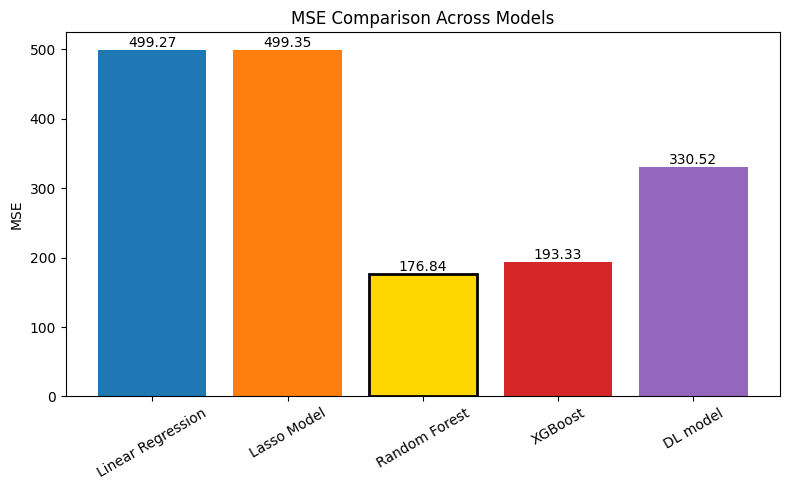

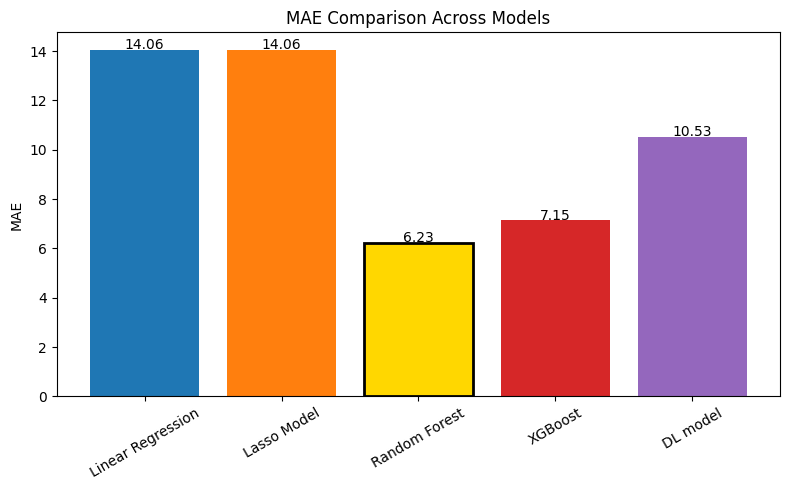

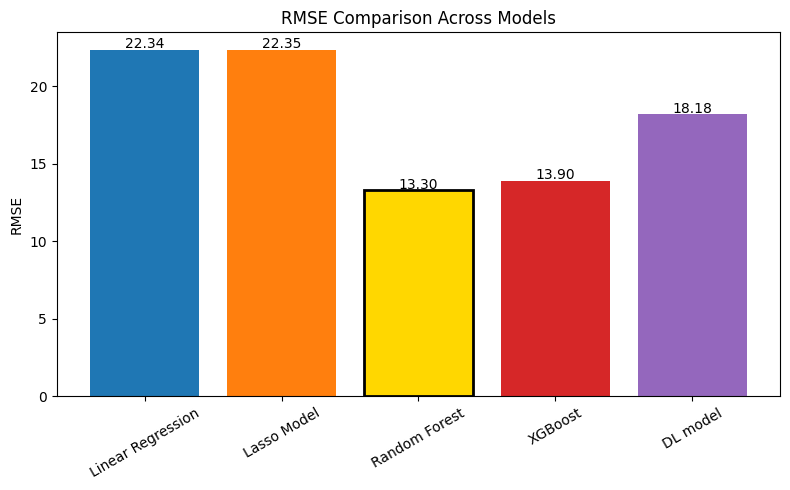

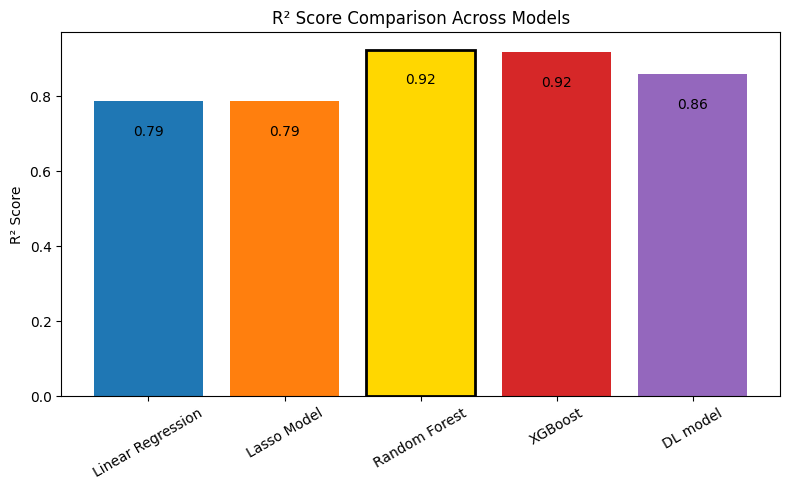

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "Metric": ["MSE", "MAE", "RMSE", "R² Score"],
    "Linear Regression": [499.27, 14.06, 22.34, 0.786],
    "Lasso Model": [499.35, 14.06, 22.35, 0.786],
    "Random Forest": [176.84, 6.23, 13.30, 0.924],
    "XGBoost": [193.33, 7.15, 13.90, 0.917],
    "DL model": [330.52, 10.53, 18.18, 0.859],
}


df = pd.DataFrame(data)
df.set_index("Metric", inplace=True)
models = df.columns

# Colors
model_colors = {
    "Linear Regression":'#1f77b4',
    "Lasso Model": '#ff7f0e',
    "Random Forest": '#2ca02c',
    "XGBoost": '#d62728',
    "DL model": '#9467bd'
}

# Plot one graph per metric
for metric in df.index:
    plt.figure(figsize=(8, 5))
    
    values = df.loc[metric]
    bars = plt.bar(models, values, color=[model_colors[model] for model in models])
    
    # Highlight best model (min for error metrics, max for R²)
    if metric != "R² Score":
        best_model = values.idxmin()
    else:
        best_model = values.idxmax()
    
    best_idx = models.get_loc(best_model)
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    # Add value labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval - 0.1, f"{yval:.2f}", ha='center', va='bottom')

    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()



When we compare the all 5 models above then we see that Random Forest model's performance is better than XGBoost and others. Therefore, we will proceed next steps with Random Forest model



| Metric       | Linear Regression | Lasso Model | Random Forest | XGBoost | DL model | Winner              |
|--------------|-------------------|-------------|---------------|---------|----------|---------------------|
| **MSE**      | 499.27            | 499.35      | **176.84**    | 193.33  | 330.52   | 🏆**Random Forest** |
| **MAE**      | 14.06             | 14.06       | **6.23**      | 7.15    | 10.53    | 🏆**Random Forest** |
| **RMSE**     | 22.34             | 22.35       | **13.30**     | 13.90   | 18.18    | 🏆**Random Forest** |
| **R² Score** | 0.786             | 0.786       | **0.924**     | 0.917   | 0.859    | 🏆**Random Forest** |


